In [12]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from NanoparticlesSAM.particle_stats import *
from NanoparticlesSAM.particle_seg import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
foldername = 'results/20250324/'
pickels = glob.glob(f'{foldername}/*pkl')

df_list = []
for file in pickels:
    df_list.append(pd.read_pickle(file))

df = pd.concat(df_list)
#df['nm_per_pixel']  = df['nm_estimated_radius'] / df['estimated_radius']

In [14]:
df.head()

,segmentation,area,bbox,predicted_iou,point_coords,stability_score,crop_box,smooth_mask,perimeter,smooth_area,...,estimated_radius,point_coords_tuple,feret_diameter,min_feret_diameter,nm_feret_radius,nm_estimated_radius,nm_min_feret_diameter,img_name,experiment,nm_per_pixel
0,"[[False, False, False, False, False, False, Fa...",25584,"[888, 583, 179, 179]",1.017580,"[[1034.638888888889, 620.6388888888889]]",0.992140,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",721,25584.0,...,90.242119,"(1034.638888888889, 620.6388888888889)",184.878338,179.000000,115.548961,112.802649,223.750000,A Immo 01,A-immo,1.25
1,"[[False, False, False, False, False, False, Fa...",25073,"[237, 725, 180, 173]",1.017815,"[[379.66666666666663, 763.5277777777778]]",0.992373,"[0, 317, 804, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",709,25072.0,...,89.336352,"(379.66666666666663, 763.5277777777778)",181.231896,173.000000,113.269935,111.670440,216.250000,A Immo 01,A-immo,1.25
2,"[[False, False, False, False, False, False, Fa...",25942,"[298, 109, 178, 183]",1.026191,"[[469.00000000000006, 196.7777777777778]]",0.992901,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",725,25941.0,...,90.871310,"(469.00000000000006, 196.7777777777778)",185.647515,177.460754,116.029697,113.589138,221.825943,A Immo 01,A-immo,1.25
3,"[[False, False, False, False, False, False, Fa...",26201,"[250, 298, 183, 180]",1.023024,"[[379.66666666666663, 339.8888888888889]]",0.992508,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",731,26201.0,...,91.323805,"(379.66666666666663, 339.8888888888889)",186.967912,178.263672,116.854945,114.154756,222.829590,A Immo 01,A-immo,1.25
4,"[[False, False, False, False, False, False, Fa...",26062,"[763, 707, 184, 181]",1.016518,"[[945.4166666666667, 799.25]]",0.992356,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",735,26062.0,...,91.081240,"(945.4166666666667, 799.25)",187.323250,175.362488,117.077031,113.851550,219.203110,A Immo 01,A-immo,1.25


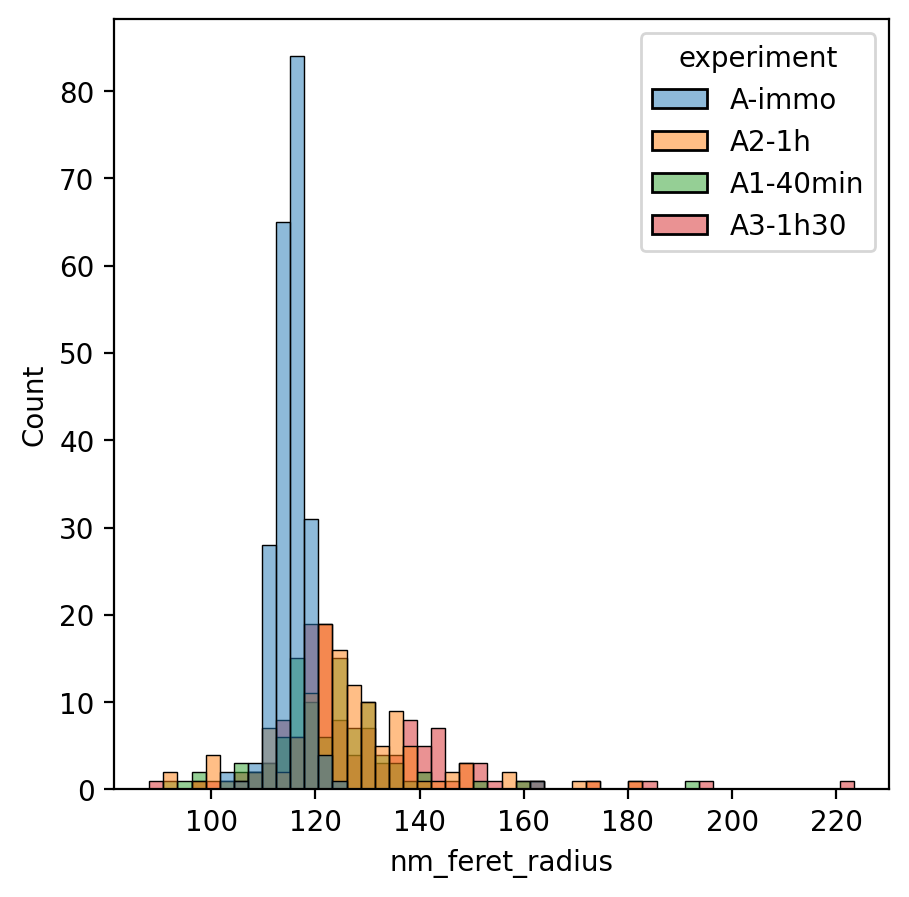

In [15]:
plt.figure(figsize=(5,5), dpi=200)
sns.histplot(data=df, x='nm_feret_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [26]:
#exclusion_list = ['A1-01', 'A1-04', 'A1-02', 'B3-01','B2-05','B2-04','B2-03','B2-02'] #20250224
exclusion_list = [ 'A1-04', 'A1-12', 'A1-17','A1-18','A1-19', 'A2-08', 'A3-15', 'A3-16', 'A3-17', 'A3-20'] #20250324


In [43]:
df_filtered = df[~df['img_name'].isin(exclusion_list)]
df_filtered.shape

(541, 21)

In [44]:
df_filtered = df_filtered.query("circularity > 0.65")
df_filtered.shape

(466, 21)

In [45]:
df_filtered['hough_radius'] = df_filtered.apply(lambda x: get_hough_radius(x['smooth_mask'], 
                                                                           dp=2, 
                                                                           nm_min_radius=70, 
                                                                           nm_max_radius=150, 
                                                                           nm_per_pixel=x['nm_per_pixel'], 
                                                                           convert_to_nm=True), axis=1)

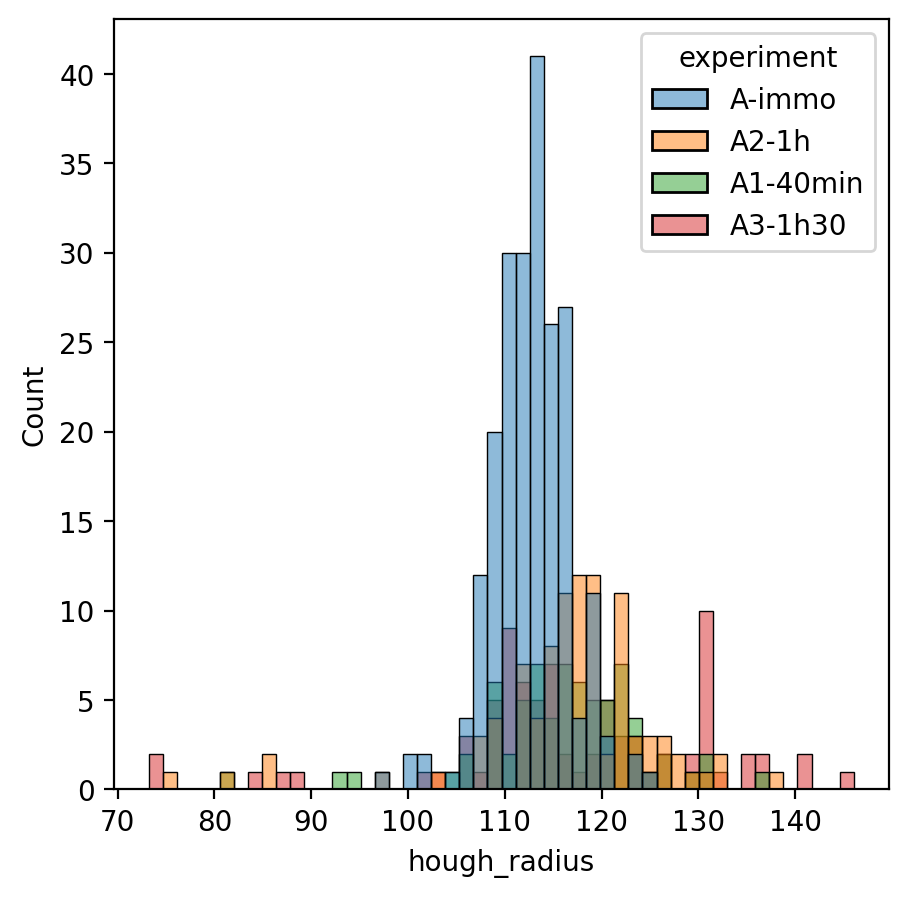

In [32]:
plt.figure(figsize=(5,5), dpi=200)

sns.histplot(data=df_filtered.dropna(), x='hough_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [46]:
filter_quantity =  'hough_radius' 
#filter_quantity = 'nm_feret_radius' 
q5, q95 = df_filtered[filter_quantity].quantile([0.05, 0.95])
df_filtered = df_filtered[(df_filtered[filter_quantity] < q95) & (df_filtered[filter_quantity] > q5)]

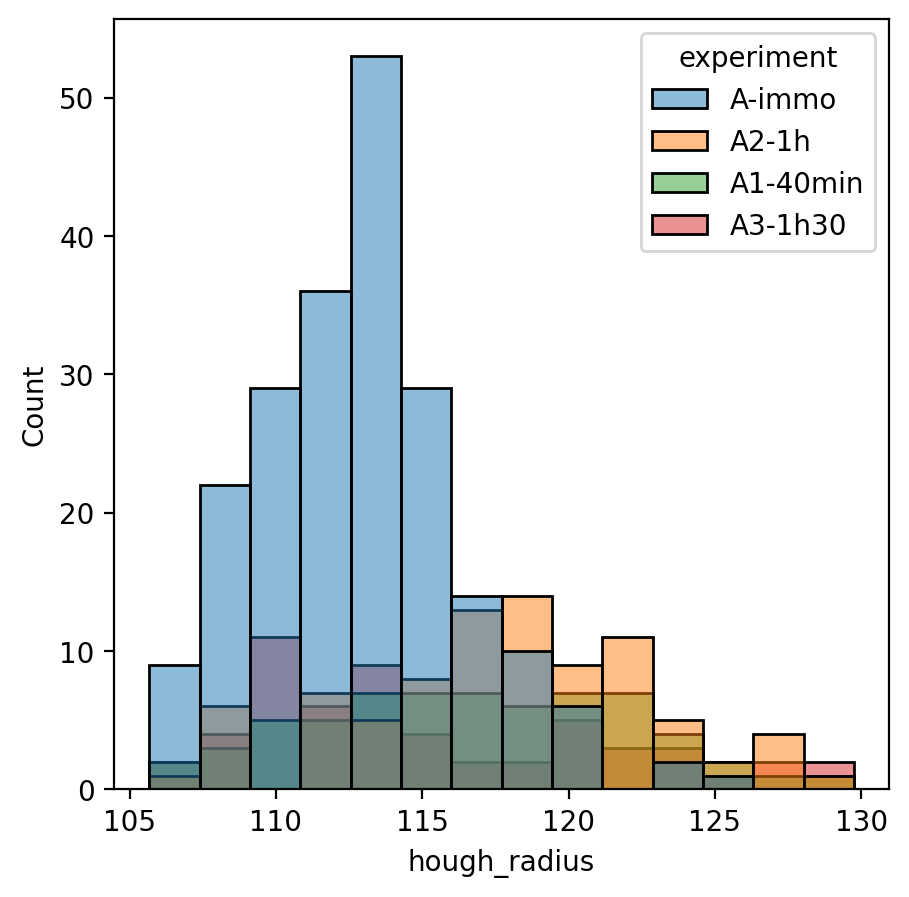

In [47]:
plt.figure(figsize=(5,5), dpi=200)
plot_df = df_filtered.dropna()
sns.histplot(data=plot_df, x=filter_quantity, hue='experiment')
plt.savefig(f'{foldername}/filtered_particle_measurements')

<Figure size 1000x1000 with 0 Axes>

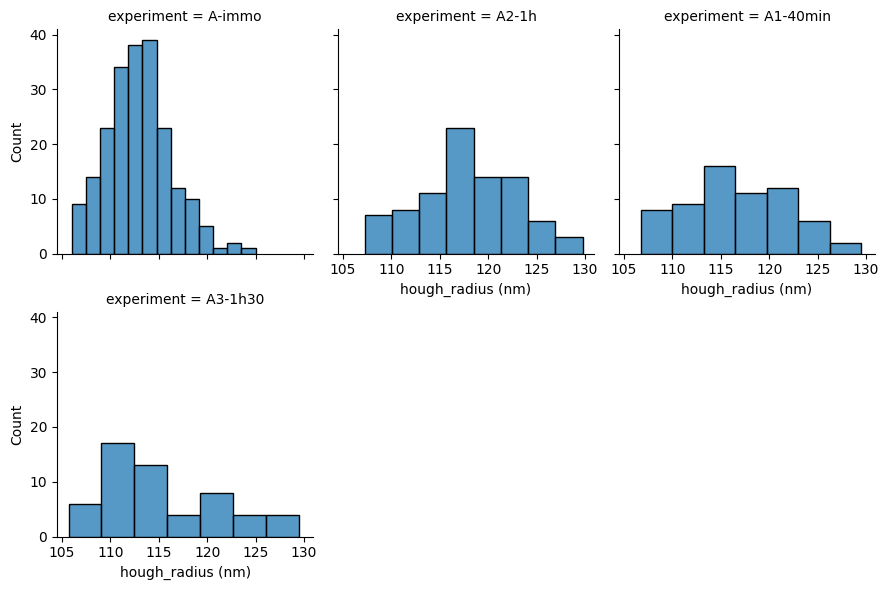

In [48]:
plt.figure(figsize=(5,5), dpi=200)
g = sns.FacetGrid(plot_df, col='experiment', col_wrap=3)
g.map(sns.histplot, filter_quantity)
g.set_axis_labels(f"{filter_quantity} (nm)", "Count")
plt.savefig(f'{foldername}/histogram-grid')

In [52]:
filter_quantity =  'hough_radius' 
filter_quantity = 'nm_feret_radius' 
experiment_df = df_filtered.reset_index().pivot(columns='experiment', values=filter_quantity)
experiment_df = experiment_df.apply(lambda x: pd.Series(x.dropna().values))
#experiment_df = remove_outliers_df(experiment_df)
experiment_df.head()

experiment,A-immo,A1-40min,A2-1h,A3-1h30
0,115.548961,117.639545,123.847815,133.488354
1,113.269935,120.276374,118.151452,113.765452
2,116.029697,126.395337,121.182326,130.458926
3,116.854945,130.006009,120.675184,138.609163
4,117.077031,128.604286,121.830120,121.050093


In [53]:
experiment_df.describe().to_excel(f'{foldername}/individual-particle-analysis.xlsx')
experiment_df.describe()

experiment,A-immo,A1-40min,A2-1h,A3-1h30
count,211.000000,64.000000,86.000000,56.000000
mean,115.487017,123.332125,125.033748,126.055466
std,2.742845,6.961214,6.926030,9.731209
min,102.355080,111.958768,100.952495,113.765452
25%,113.724242,117.488905,121.149684,120.231489
50%,115.559103,123.521673,124.047936,122.626114
75%,117.395232,126.586181,129.965518,130.501939
max,123.833621,150.960467,139.320337,162.792011


In [54]:
analysis_df = analyze_samples(experiment_df, 'A-immo', alpha=0.01)
analysis_df.to_csv(f'{foldername}/shield-analysis.csv')
analysis_df.to_excel(f'{foldername}/shield-analysis.xlsx')
analysis_df

,A1-40min,A2-1h,A3-1h30
thickness,7.845108,9.546731,10.568449
CI_lower,5.486475,7.522254,7.067452
CI_upper,10.203741,11.571209,14.069447
p_value,0.0,0.0,0.0
significance,Significant,Significant,Significant
significance_level,99.5,99.5,99.5
SEM,0.890404,0.770353,1.314025
DOF,69.027139,96.055172,57.33713
N_sample,64,86,56
N_ref,211,211,211


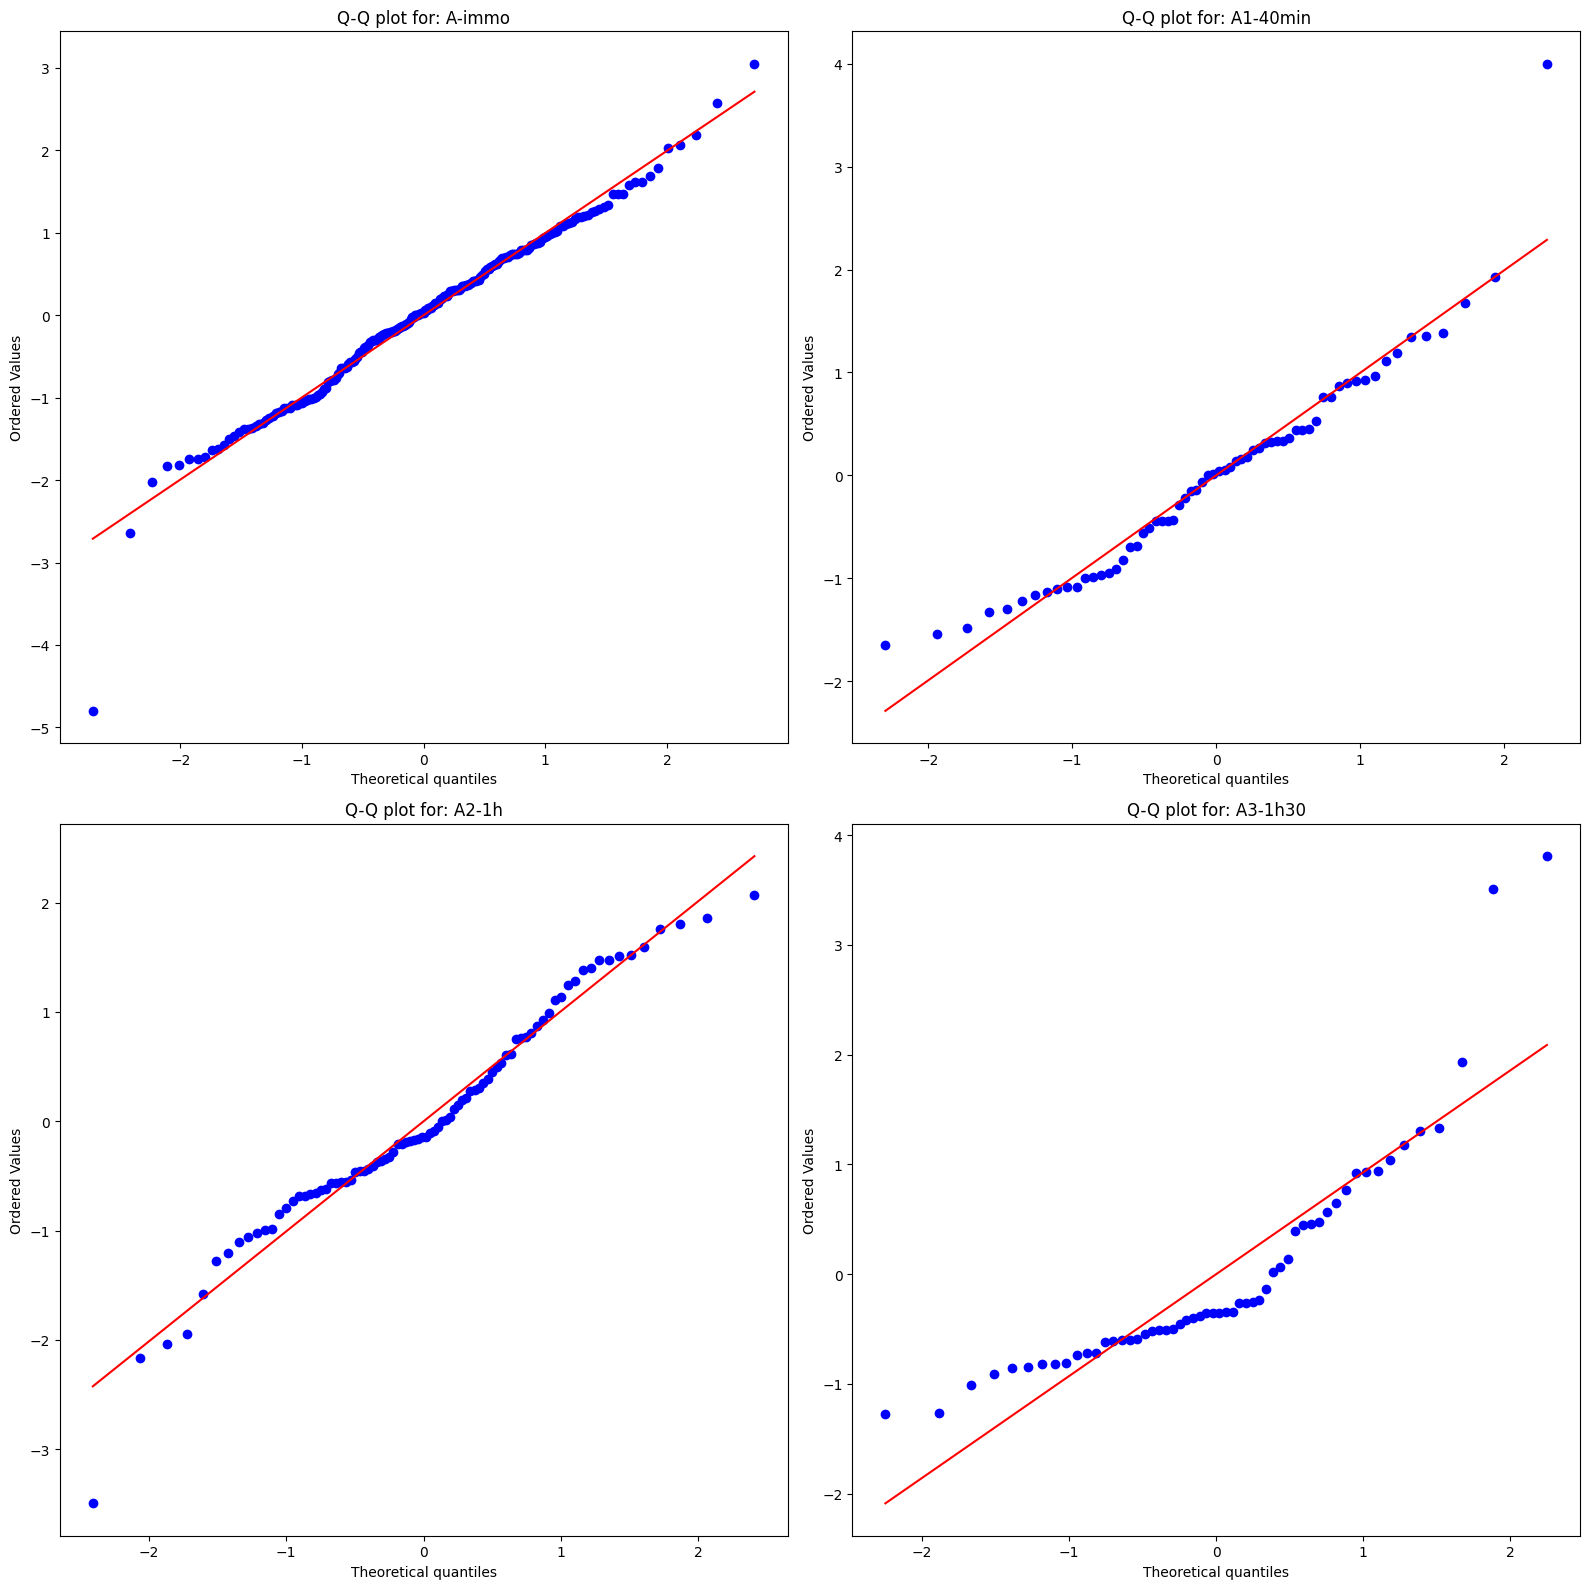

<Figure size 640x480 with 0 Axes>

In [55]:
plot_quantiles(experiment_df, foldername)